In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
all_data_joined <- read.csv('datas_and_notebooks/final_datas/all_data_joined.csv') |> 
  select(-month) |> 
  filter(!is.na(id)) |> 
  mutate(
    species = ifelse(species == "rosa", "rosa sp.", species),
    species = ifelse(species == "ilex suaveolens" & genus == "lindera", "lindera reflexa", species),
    species = ifelse(id == 1168, "clerodendrum cyrtophyllum", species),
    species = ifelse(str_detect(species, "machilus gri"), "machilus grijsii", species),
    species = ifelse(id == 1190, "lindera reflexa", species),
    species = ifelse(id == 1122, "not liquidamber", species)
  ) |> 
  filter(
    !(str_detect(species, "ilex ficoidea") & str_detect(genus, "loropetalum") & str_detect(as.character(id), "1072")),
    !(id == 117 & is.na(species))
  ) |>
  group_by(id, species) |> 
  mutate(
    seed_source_short = ifelse(
      seed_source_short == "" | is.na(seed_source_short),
      na.omit(seed_source_short)[1],
      seed_source_short
    )
  ) |>
  distinct() |> 
  ungroup()

In [3]:
str(all_data_joined)

tibble [4,011 × 44] (S3: tbl_df/tbl/data.frame)
 $ date                   : chr [1:4011] "2024-05-26" "2024-05-26" "2024-05-26" "2024-05-26" ...
 $ site                   : chr [1:4011] "a" "a" "a" "a" ...
 $ plot                   : chr [1:4011] "ac32" "ac32" "ac32" "ac32" ...
 $ subplot                : chr [1:4011] "ac32-i" "ac32-i" "ac32-i" "ac32-i" ...
 $ diversity              : int [1:4011] 2 2 2 2 2 2 2 2 2 2 ...
 $ id                     : chr [1:4011] "276" "327" "597" "1658" ...
 $ species                : chr [1:4011] "lindera reflexa" "lindera reflexa" "lindera reflexa" "seedling" ...
 $ genus                  : chr [1:4011] "lindera" "lindera" "lindera" NA ...
 $ family                 : chr [1:4011] "lauraceae" "lauraceae" "lauraceae" NA ...
 $ growth_form            : chr [1:4011] "shrub/tree" "shrub/tree" "shrub/tree" NA ...
 $ seed_source_short      : chr [1:4011] "EI" "EI" "EI" NA ...
 $ tot_veg                : num [1:4011] 0.5 0.5 0.5 0.5 0.5 0.5 0.65 0.65 0.75 0.7

In [4]:
all_data_joined |> 
  distinct(id, species) |> 
  group_by(id) |> 
  filter(n() > 1)

New names:
• `` -> `...1`


id,species
<chr>,<chr>
716,camellia sinensis
349,ilex suaveolens
1420,seedling
1592,recruit
290,seedling
1697,seedling
308,loropetalum chinense
1965,seedling
399,adinandra millettii


In [5]:
all_data_joined |> 
 # select(-date) |>
  group_by(id, subplot) |> 
  filter(n_distinct(species) > 1) |> 
  ungroup()

date,site,plot,subplot,diversity,id,species,genus,family,growth_form,⋯,number_necrotic_damaged,percent_necrose,percent_nmin,percent_nmax,notes2,year,type,percent_herb,saplings,seedlings
<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<dbl>,<int>,<int>
2024-05-26,a,ac32,ac32-iv,2,716,camellia sinensis,camellia,theaceae,shrub/tree,⋯,0,0,NA,NA,largely outside plot,2024,NA,NA,NA,NA
2024-05-26,a,ac32,ac32-iv,2,716,camellia sinensis,nyssa,nyssaceae,tree,⋯,0,0,NA,NA,largely outside plot,2024,NA,NA,NA,NA
2024-05-26,a,ac32,ac32-iv,2,349,ilex suaveolens,ilex,aquifoliaceae,shrub/tree,⋯,NA,NA,NA,NA,same individual as 1740,2024,NA,NA,NA,NA
2024-05-26,a,ac32,ac32-iv,2,349,ilex suaveolens,osmanthus,oleaceae,shrub/tree,⋯,NA,NA,NA,NA,same individual as 1740,2024,NA,NA,NA,NA
2024-05-26,a,ac32,ac32-iv,2,1420,seedling,unknown,unknown,unknown,⋯,NA,NA,NA,NA,NA,2024,NA,NA,NA,NA
2024-05-20,a,ae31,ae31-iii,1,290,seedling,quercus,fagaceae,tree,⋯,NA,NA,NA,NA,NA,2024,NA,NA,NA,NA
2024-05-20,a,ae31,ae31-iii,1,1697,seedling,unknown,unknown,unknown,⋯,NA,NA,NA,NA,NA,2024,NA,NA,NA,NA
2024-05-20,a,ae31,ae31-iv,1,308,loropetalum chinense,loropetalum,hamamelidaceae,shrub,⋯,0,0,NA,NA,4b,2024,NA,NA,NA,NA
2024-05-20,a,ae31,ae31-iv,1,308,loropetalum chinense,rhododendron,ericaceae,shrub/tree,⋯,0,0,NA,NA,4b,2024,NA,NA,NA,NA


In [6]:
str(all_data_joined)

tibble [4,011 × 44] (S3: tbl_df/tbl/data.frame)
 $ date                   : chr [1:4011] "2024-05-26" "2024-05-26" "2024-05-26" "2024-05-26" ...
 $ site                   : chr [1:4011] "a" "a" "a" "a" ...
 $ plot                   : chr [1:4011] "ac32" "ac32" "ac32" "ac32" ...
 $ subplot                : chr [1:4011] "ac32-i" "ac32-i" "ac32-i" "ac32-i" ...
 $ diversity              : int [1:4011] 2 2 2 2 2 2 2 2 2 2 ...
 $ id                     : chr [1:4011] "276" "327" "597" "1658" ...
 $ species                : chr [1:4011] "lindera reflexa" "lindera reflexa" "lindera reflexa" "seedling" ...
 $ genus                  : chr [1:4011] "lindera" "lindera" "lindera" NA ...
 $ family                 : chr [1:4011] "lauraceae" "lauraceae" "lauraceae" NA ...
 $ growth_form            : chr [1:4011] "shrub/tree" "shrub/tree" "shrub/tree" NA ...
 $ seed_source_short      : chr [1:4011] "EI" "EI" "EI" NA ...
 $ tot_veg                : num [1:4011] 0.5 0.5 0.5 0.5 0.5 0.5 0.65 0.65 0.75 0.7

# Preparation of data for Matteo

## Summary: Requested Data and Relevant Variables

Based on the emails, the collaborator is interested in the following types of understorey data, ideally at the **subplot level** and for the year **2023** (June/July):

### 1. Understorey Cover
- **Variable(s) of interest:** 
  - `tot_veg` (total vegetation cover, numeric)
  - `herb_max`(height of herb layer)
  - `grass` (cover of different functional groups, numeric)
- **Purpose:** To quantify the percentage of understorey cover, both total and by functional group.

### 2. Understorey Diversity
- **Variable(s) of interest:** 
  - `species` (to count number of unique species per subplot)
  - `diversity` (if this is a pre-calculated species count)
- **Purpose:** To provide the number of understorey species per subplot (species richness), **without species IDs**.

### 3. Understorey Structure / Heterogeneity
- **Variable(s) of interest:** 
  - Proportions of different functional groups: `herb_max`, `grass`, `fern`, `herbaceous`, `woody`
- **Purpose:** 
  - To assess the structural heterogeneity of the understorey (e.g., relative abundance of functional groups).
  - To provide the **maximum understorey height** per subplot, especially if it exceeds 2 m (to distinguish from canopy).

### 4. Other Potential Predictors of Insect Presence/Richness
- **Variable(s) of interest:** 
  - `open_ground`, `rock`, `leaflitter`, `leaflitter_dept`, `deadwood`, `moss` (microhabitat features)
- **Purpose:** These variables may be relevant as predictors of decomposer/insect presence and richness.

---

## Summary Table of Relevant Variables

| Variable Name         | Description                                      | Type      |
|----------------------|--------------------------------------------------|-----------|
| tot_veg              | Total vegetation cover (%)                       | Numeric   |
| herb_max             | Max herb      (cm)                               | Integer   |
| grass, fern, etc.    | Cover of specific functional groups (%)          | Numeric   |
| diversity            | Number of species (if pre-calculated)            | Integer   |
| species              | Species name (for calculating richness)          | Character |
| height               | Height of understorey (cm or m)                  | Numeric   |
| open_ground, rock    | Cover of open ground, rock (%)                   | Numeric   |
| leaflitter, deadwood | Cover/depth of leaf litter, deadwood (%)         | Numeric   |
| moss                 | Moss cover (%)                                   | Numeric   |

---

## Notes

- Data should be **aggregated at the subplot level** (i.e., per unique combination of `site`, `plot`, `subplot`).
- For diversity, only the **number of species** per subplot is needed, not species identities.
- For structure, **proportions of functional groups** and **maximum understorey height** are requested.
- If available, **microhabitat variables** (e.g., leaf litter, deadwood, moss) may also be useful as predictors.

---

In [7]:
str(all_data_joined)

tibble [4,011 × 44] (S3: tbl_df/tbl/data.frame)
 $ date                   : chr [1:4011] "2024-05-26" "2024-05-26" "2024-05-26" "2024-05-26" ...
 $ site                   : chr [1:4011] "a" "a" "a" "a" ...
 $ plot                   : chr [1:4011] "ac32" "ac32" "ac32" "ac32" ...
 $ subplot                : chr [1:4011] "ac32-i" "ac32-i" "ac32-i" "ac32-i" ...
 $ diversity              : int [1:4011] 2 2 2 2 2 2 2 2 2 2 ...
 $ id                     : chr [1:4011] "276" "327" "597" "1658" ...
 $ species                : chr [1:4011] "lindera reflexa" "lindera reflexa" "lindera reflexa" "seedling" ...
 $ genus                  : chr [1:4011] "lindera" "lindera" "lindera" NA ...
 $ family                 : chr [1:4011] "lauraceae" "lauraceae" "lauraceae" NA ...
 $ growth_form            : chr [1:4011] "shrub/tree" "shrub/tree" "shrub/tree" NA ...
 $ seed_source_short      : chr [1:4011] "EI" "EI" "EI" NA ...
 $ tot_veg                : num [1:4011] 0.5 0.5 0.5 0.5 0.5 0.5 0.65 0.65 0.75 0.7

In [8]:
library(dplyr)

# Only keep the first measurement (earliest date) per subplot
matteo_data_per_subplot <- all_data_joined |> 
  filter(year == 2023) |> 
  #slice(1) |> 
  ungroup() |> 
  rename("tree_diversity" = diversity) |> 
  group_by(subplot, date, tree_diversity, tot_veg, herb_max, grass, fern, herbaceous, woody, open_ground, rock, leaflitter, leaflitter_dept, moss) |> 
  summarise(
    n_species = n_distinct(species),
    .groups = "drop"
  ) |> 
group_by(subplot) |> 
  arrange(date) |> 
  slice(1)

In [9]:
matteo_data_per_subplot

New names:
• `` -> `...1`


subplot,date,tree_diversity,tot_veg,herb_max,grass,fern,herbaceous,woody,open_ground,rock,leaflitter,leaflitter_dept,moss,n_species
<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
ac32-i,2023-07-01,2,0.25,27,0.030,0.000,0.010,0.200,NA,0.00,0.05,NA,0.030,1
ac32-ii,2023-07-01,2,0.40,82,0.010,0.150,0.100,0.150,NA,0.00,0.02,NA,0.100,2
ac32-iii,2023-07-01,2,0.30,48,0.001,0.150,0.050,0.100,NA,0.00,0.40,NA,0.000,2
ac32-iv,2023-07-01,2,0.20,32,0.020,0.050,0.050,0.050,NA,0.00,0.05,NA,0.050,3
ae31-i,2023-06-18,1,0.05,20,0.001,0.010,0.001,0.020,NA,0.00,0.20,NA,0.020,1
ae31-ii,2023-06-18,1,0.10,35,0.000,0.050,0.010,0.050,NA,0.00,0.40,NA,0.001,1
ae31-iii,2023-06-18,1,0.40,39,0.001,0.050,0.001,0.350,NA,0.00,0.50,NA,0.010,3
ae31-iv,2023-06-18,1,0.05,27,0.001,0.001,0.001,0.010,NA,0.00,0.05,NA,0.001,2
ae33-ii,2023-06-18,1,0.02,9,0.000,0.010,0.000,0.010,NA,0.00,0.70,NA,0.050,1


In [10]:
write.csv(matteo_data_per_subplot, "datas_and_notebooks/extra_data/matteo_data.csv", row.names = FALSE)

# Include light logger data

In [11]:
library(readxl)

# List all sheet names in the Excel file
sheet_names <- excel_sheets("datas_and_notebooks/light_logger/Light logger data September 2023.xlsx")

# Read all sheets into a named list of dataframes
light_logger_data_list <- lapply(sheet_names, function(sheet) {
  read_excel("datas_and_notebooks/light_logger/Light logger data September 2023.xlsx", sheet = sheet)
})
names(light_logger_data_list) <- sheet_names

New names:
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`


In [12]:
library(janitor)
library(dplyr)
library(stringr)

light_logger_data_list <- lapply(light_logger_data_list, function(df) {
  df <- as_tibble(df)
  df <- clean_names(df)
  df <- df %>%
    mutate(across(where(is.character), ~ tolower(str_trim(.))))
  return(df)
})

# Turn the first row in $`A ref` to the colname
light_logger_data_list[["A ref"]] <- light_logger_data_list[["A ref"]] |> 
  (\(x) {
    colnames(x) <- as.character(unlist(x[1, ]))
    x[-1, ]
  })()


Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




In [13]:
# Convert Excel numeric date to Date format in "A ref"
light_logger_data_list[["A ref"]] <- light_logger_data_list[["A ref"]] |> 
  mutate(date = as.Date(as.numeric(date), origin = "1899-12-30"))

# Check structure again
light_logger_data_list |> 
  str()

List of 5
 $ A ref   : tibble [11,933 × 6] (S3: tbl_df/tbl/data.frame)
  ..$ datah : chr [1:11933] "data" "data" "data" "data" ...
  ..$ record: chr [1:11933] "0" "1" "2" "3" ...
  ..$ date  : Date[1:11933], format: "2023-09-09" "2023-09-09" ...
  ..$ time  : chr [1:11933] "07:47:34.000" "07:47:39.000" "07:47:44.000" "07:47:49.001" ...
  ..$ input2: chr [1:11933] "129.91999999999999" "23398" "135.88" "140.37" ...
  ..$ chk   : chr [1:11933] "42" "50" "47" "44" ...
 $ B ref   : tibble [12,753 × 6] (S3: tbl_df/tbl/data.frame)
  ..$ datah : chr [1:12753] "data" "data" "data" "data" ...
  ..$ record: num [1:12753] 0 1 2 3 4 5 6 7 8 9 ...
  ..$ date  : POSIXct[1:12753], format: "2023-09-23" "2023-09-23" ...
  ..$ time  : chr [1:12753] "07:06:21.000" "07:06:26.000" "07:06:31.000" "07:06:36.001" ...
  ..$ input2: num [1:12753] 150 159 162 159 165 ...
  ..$ chk   : num [1:12753] 23 35 27 41 34 41 36 43 45 42 ...
 $ Tabelle1: tibble [0 × 0] (S3: tbl_df/tbl/data.frame)
 Named list()
 $ A plots :

In [14]:
library(dplyr)
library(lubridate)
library(purrr)

# Helper function to find nearest datetime in reference for each plot row and add an id
find_nearest <- function(ref_df, plot_df, ref_date_col, ref_time_col, plot_date_col, plot_time_col) {
  # Create POSIXct datetime columns
  ref_df <- ref_df %>%
    mutate(datetime = as.POSIXct(paste(!!sym(ref_date_col), !!sym(ref_time_col)), format = "%Y-%m-%d %H:%M:%OS", tz = "UTC"))
  plot_df <- plot_df %>%
    mutate(datetime = as.POSIXct(paste(!!sym(plot_date_col), !!sym(plot_time_col)), format = "%Y-%m-%d %H:%M:%OS", tz = "UTC"))
  
  # For each plot row, find the index of the nearest ref datetime
  nearest_idx <- sapply(plot_df$datetime, function(dt) {
    which.min(abs(difftime(ref_df$datetime, dt, units = "secs")))
  })
  
  # Assign a unique id to each plot row and corresponding ref row
  plot_df <- plot_df %>%
    mutate(nearest_ref_idx = nearest_idx, join_id = row_number())
  ref_df <- ref_df %>%
    mutate(join_id = NA_integer_)
  ref_df$join_id[unique(nearest_idx)] <- which(unique(nearest_idx) %in% nearest_idx)
  
  # Keep only those rows in ref_df that are nearest to any plot row
  ref_df_nearest <- ref_df[unique(nearest_idx), ]
  
  # Also return the plot_df with join_id for later joining
  list(ref = ref_df_nearest, plot = plot_df)
}

# For A ref and A plots
A_ref <- light_logger_data_list[["A ref"]]
A_plots <- light_logger_data_list[["A plots"]]

A_nearest <- find_nearest(
  ref_df = A_ref,
  plot_df = A_plots,
  ref_date_col = "date",
  ref_time_col = "time",
  plot_date_col = "date",
  plot_time_col = "time"
)
A_ref_nearest <- A_nearest$ref
A_plots_with_id <- A_nearest$plot

# For B ref and B plots
B_ref <- light_logger_data_list[["B ref"]]
B_plots <- light_logger_data_list[["B plots"]]

B_nearest <- find_nearest(
  ref_df = B_ref,
  plot_df = B_plots,
  ref_date_col = "date",
  ref_time_col = "time",
  plot_date_col = "date",
  plot_time_col = "time"
)
B_ref_nearest <- B_nearest$ref
B_plots_with_id <- B_nearest$plot

# Overwrite the original dataframes in the list with the filtered ones and add the id columns
light_logger_data_list[["A ref"]] <- A_ref_nearest
light_logger_data_list[["A plots"]] <- A_plots_with_id
light_logger_data_list[["B ref"]] <- B_ref_nearest
light_logger_data_list[["B plots"]] <- B_plots_with_id

In [15]:
# Remove columns 'datah', 'record', 'chk' from each dataframe in light_logger_data_list
light_logger_data_list_selected <- lapply(light_logger_data_list, function(df) df[ , !(names(df) %in% c("datah", "record", "chk", "datetime", "time", "date", "nearest_ref_idx")) ])

In [16]:
light_logger_data_list_selected

input2,join_id
<chr>,<int>
280.63,1
286.39999999999998,2
290.5,3
307.26,4
326.86,5
325.83,6
324.14,7
321.88,8
170.03,9


In [17]:
library(dplyr)

# Perform full_join on the first two dataframes in light_logger_data_list_selected for light_a
light_a <- full_join(light_logger_data_list_selected$`A ref`, light_logger_data_list_selected$`A plots`)

# Perform full_join on the third and fourth dataframes in light_logger_data_list_selected for light_b
light_b <- full_join(light_logger_data_list_selected$`B ref`, light_logger_data_list_selected$`B plots`)

Joining with `by = join_by(join_id)`
Joining with `by = join_by(join_id)`


In [18]:
# Define the original and replacement values as character vectors
original_values <- c("15", "18710", "20", "21521", "22643", "23203", "23756", "25569", "28", "28847", "31", "40228", "41342", "46235", "61139", "67942", "10797", "14601", "24812", "28816", "5024", "51216", "57358", "71794", "10155", "10207", "10215", "10251", "10548", "11518", "11880", "12044", "12547", "12968", "13457", "13855", "13956", "14393", "15140", "16101", "16421", "16926", "16956", "17680", "17914", "18395", "19032", "22356", "22441", "23000", "23779", "25176", "30153", "31241", "31341", "31710", "32062", "32230", "32275", "32695", "33458", "33925", "35670", "35827", "38750", "39484", "39501", "39511", "41416", "41715", "42036", "43078", "43378", "45444", "47506", "52882", "53115", "53906", "54048", "54056", "54172", "55135", "55276", "55280", "57241", "57907", "58714", "59574", "62606", "63621", "64065", "64151", "64487", "64651", "66567", "66623", "68825", "70067", "75846", "75856", "76254", "76682", "76919", "80460", "80709", "80931", "81233", "83797", "85213", "85304", "86377", "87514", "87992", "88705", "93657", "95370", "95528", "95725", "97752", "98016", "98945", "99201", "10017", "11054", "12190", "12986", "13114", "13893", "14069", "14775", "16270", "18234", "20592", "22238", "31318", "32134", "72239", "74703", "75249", "79357")
replacement_values <- c("15", "18.710", "20", "21.521", "22.643", "23.203", "23.756", "25.569", "28", "28.847", "31", "40.228", "41.342", "46.235", "61.139", "67.942", "107.97", "146.01", "248.12", "288.16", "502.4", "512.16", "573.58", "717.94", "10.155", "10.207", "10.215", "10.251", "10.548", "11.518", "11.880", "12.044", "12.547", "12.968", "13.457", "13.855", "13.956", "14.393", "15.140", "16.101", "16.421", "16.926", "16.956", "17.680", "17.914", "18.395", "19.032", "22.356", "22.441", "23.000", "23.779", "25.176", "30.153", "31.241", "31.341", "31.710", "32.062", "32.230", "32.275", "32.695", "33.458", "33.925", "35.670", "35.827", "38.750", "39.484", "39.501", "39.511", "41.416", "41.715", "42.036", "43.078", "43.378", "45.444", "47.506", "52.882", "53.115", "53.906", "54.048", "54.056", "54.172", "55.135", "55.276", "55.280", "57.241", "57.907", "58.714", "59.574", "62.606", "63.621", "64.065", "64.151", "64.487", "64.651", "66.567", "66.623", "68.825", "70.067", "75.846", "75.856", "76.254", "76.682", "76.919", "80.460", "80.709", "80.931", "81.233", "83.797", "85.213", "85.304", "86.377", "87.514", "87.992", "88.705", "93.657", "95.370", "95.528", "95.725", "97.752", "98.016", "98.945", "99.201", "100.17", "1105.4", "1219.0", "129.86", "131.14", "1389.3", "1406.9", "147.75", "162.70", "182.34", "205.92", "222.38", "313.18", "321.34", "722.39", "747.03", "752.49", "793.57")

# Replace values in light_a$input1
light_a$input1 <- ifelse(light_a$input1 %in% original_values,
                         replacement_values[match(light_a$input1, original_values)],
                         light_a$input1)

In [19]:
# Define the mapping from old to new values
old_values <- c("40200", "30140", "22812", "22567", "78193", "19145", "11310", "12716", "94265", "82704", "84506", "11976", "77169", "36372", "87156", "99071", "39160", "31686", "31400", "38666", "49275", "59891", "99330", "72557", "86677", "98955", "65025", "56333", "70699", "14234", "29065", "58172", "38344", "30109", "40693", "33617", "35879", "34933", "22914", "40797", "14558", "53608", "31901", "37007", "86187", "13567", "70013", "10175", "45067", "28555", "37480", "42759", "47399", "17775", "46626", "10950", "23851", "28132", "32513", "28593", "89687", "44070", "23874", "23574", "32946", "55487", "53816", "30035", "88162", "43110", "28418", "20229", "32895", "44190", "25829", "11604", "27753", "35314", "75719", "68811", "17940", "20052", "28223", "20125", "45813", "64193", "41905", "90931", "17889", "28714", "21475", "13660", "92185", "74584", "82855", "72065", "37740", "18439", "61751", "51531", "52304", "51636", "55805", "46837", "24898", "36247", "32946", "43634", "87809", "24998", "93706", "58389", "13317", "40018", "51183", "19495", "64837", "10429", "20258", "30406", "55278", "94342", "12865", "15116", "62318", "76834", "10741", "10774", "35614", "92221", "32730", "47288", "59928", "45288", "61445", "26854")
new_values <- c(40.200, 30.140, 22.812, 22.567, 78.193, 191.45, 113.10, 127.16, 94.265, 82.704, 84.506, 11.976, 77.169, 363.72, 87.156, 99.071, 391.60, 316.86, 314.00, 386.66, 49.275, 59.891, 99.330, 72.557, 86.677, 98.955, 65.025, 56.333, 70.699, 142.34, 290.65, 58.172, 383.44, 301.09, 406.93, 336.17, 358.79, 349.33, 229.14, 407.97, 145.58, 53.608, 31.901, 37.007, 86.187, 135.67, 70.013, 101.75, 45.067, 28.555, 37.480, 42.759, 47.399, 17.775, 46.626, 109.50, 238.51, 281.32, 325.13, 285.93, 89.687, 44.070, 2387.4, 2357.4, 32.946, 55.487, 53.816, 30.035, 88.162, 43.110, 28.418, 20.229, 328.95, 441.90, 258.29, 116.04, 277.53, 353.14, 75.719, 688.11, 179.40, 200.52, 282.23, 201.25, 45.813, 64.193, 41.905, 90.931, 17.889, 28.714, 21.475, 136.60, 921.85, 745.84, 828.55, 720.65, 377.40, 184.39, 617.51, 515.31, 523.04, 516.36, 558.05, 468.37, 248.98, 362.47, 329.46, 436.34, 878.09, 249.98, 937.06, 583.89, 133.17, 400.18, 51.183, 194.95, 64.837, 104.29, 20.258, 30.406, 55.278, 94.342, 128.65, 151.16, 623.18, 768.34, 1074.1, 1077.4, 356.14, 922.21, 327.30, 472.88, 599.28, 452.88, 614.45, 268.54)

# Replace values in input1 column of light_b
light_b$input1 <- ifelse(
  as.character(light_b$input1) %in% old_values,
  new_values[match(as.character(light_b$input1), old_values)],
  light_b$input1
)

In [20]:
library(dplyr)
library(stringr)

light_a <- light_a %>%
  mutate(
    input2 = as.numeric(input2),
    input2 = case_when(
      input2 == 84604 ~ 84.604,
      input2 == 90248 ~ 90.248,
      TRUE ~ input2
    ), input1 = as.numeric(input1)
  ) |> 
 select(-join_id)

light_b <- light_b |> 
 mutate(input1 = as.numeric(input1)) |> 
 select(-join_id)

light_data_joined <- light_a |> 
 full_join(light_b)

Joining with `by = join_by(input2, plot, subplot, input1)`


In [21]:
light_data_joined <- light_data_joined %>%
  mutate(rli = input1 / input2 * 100) |> 
  select(-input1, -input2)
light_data_joined |> 
 write.csv("datas_and_notebooks/final_datas/finale_lightloggees.csv", row.names = F)
 finale_daten <- light_data_joined

Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”


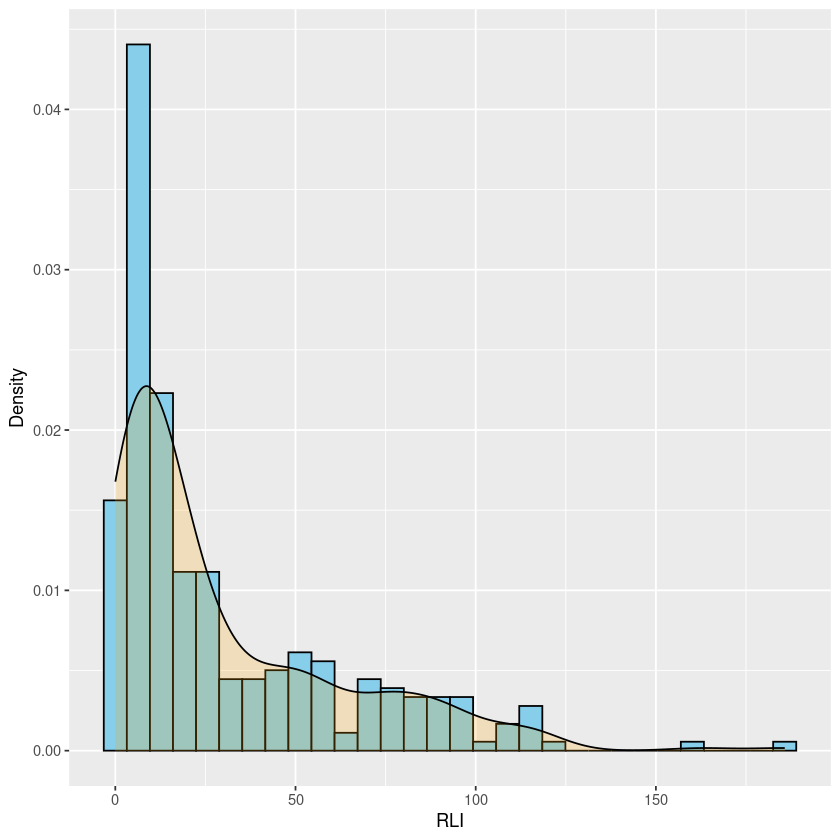

In [22]:
light_data_joined |> 
  ggplot(aes(x = rli)) + 
  geom_histogram(aes(y = ..density..), bins = 30, fill = "skyblue", color = "black") +
  geom_density(alpha = 0.2, fill = "orange") +
  labs(x = "RLI", y = "Density")

- Visualisieren der light data um zu schauen, ob sie sich ähneln zwischen den subplots
- Ausareißer nochmal überprüfen
- Monate als Zeitvariable

In [23]:
all_data_joined_lightlogger <- all_data_joined |> 
 left_join(light_data_joined) |> 
 distinct() 
saveRDS(all_data_joined_lightlogger, "datas_and_notebooks/final_datas/all_data_joined_lightlogger.rds")

Joining with `by = join_by(plot, subplot)`
Warning message in left_join(all_data_joined, light_data_joined):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 281 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


# Modelle

In [24]:
library(dplyr)

all_data_joined <- all_data_joined %>%
  arrange(subplot, as.Date(date)) %>%
  group_by(subplot) %>%
  mutate(n_measurement = dense_rank(as.Date(date))) %>%
  ungroup()

In [25]:
# Load the caret package for the train() function
library(caret)
library(dplyr)

set.seed(2022)

# Fix: Remove the extra '+' in the formula and ensure na.omit() is applied after all joins/selections
fit <- train(
  height ~ growth_form + 
    tot_veg + herb_max + grass + fern + herbaceous + woody  + leaflitter + deadwood + moss  + 
    diversity + year + rli + n_measurement,
  data = all_data_joined %>%
    left_join(finale_daten %>% select(subplot, rli), by = "subplot") %>%
    distinct() %>%
    select(height, genus, family, growth_form, 
           tot_veg, herb_max, grass, fern, herbaceous, woody, leaflitter, deadwood, moss,
           diversity, year, rli, n_measurement) %>%
    na.omit(),
  method = "glm"
)

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift


Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x

In [26]:
# Load the vip package
library(vip)

# Plot variable importance
p1 <- vip(fit$finalModel, num_features = 30) +
  labs(title = "Variable Importance for Height Prediction") + 
  theme_minimal()


Attaching package: ‘vip’


The following object is masked from ‘package:utils’:

    vi




In [27]:
fit2 <- train(
  number_leaves ~ growth_form + 
    tot_veg + herb_max + grass + fern + herbaceous + woody  + leaflitter + deadwood + moss  + 
    diversity + year + rli + n_measurement,
  data = all_data_joined %>%
    left_join(finale_daten %>% select(subplot, rli), by = "subplot") %>%
    distinct() %>%
    select(number_leaves, genus, family, growth_form, 
           tot_veg, herb_max, grass, fern, herbaceous, woody, leaflitter, deadwood, moss,
           diversity, year, rli, n_measurement) %>%
	mutate_if(is.numeric, scale) |> 
    na.omit(),
  method = "glm"
)
p2 <- vip(fit2$finalModel, num_features = 30) +
  labs(title = "Variable Importance for Number of Leaves Prediction") + 
  theme_minimal()

Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relatio

In [28]:
fit3 <- train(
  number_herb_damaged ~ growth_form + 
    tot_veg + herb_max + grass + fern + herbaceous + woody  + leaflitter + deadwood + moss  + 
    diversity + year + rli+ n_measurement,
  data = all_data_joined %>%
    left_join(finale_daten %>% select(subplot, rli), by = "subplot") %>%
    distinct() %>%
    select(number_herb_damaged, genus, family, growth_form, 
           tot_veg, herb_max, grass, fern, herbaceous, woody, leaflitter, deadwood, moss,
           diversity, year, rli, n_measurement) %>%
	mutate_if(is.numeric, scale) |> 
    na.omit(),
  method = "glm"
)
p3 <- vip(fit3$finalModel, num_features = 30) +
  labs(title = "Variable Importance for Number of herb damaged Prediction") + 
  theme_minimal()

Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relatio

In [29]:
fit4 <- train(
  number_fungal_damaged ~ growth_form + 
    tot_veg + herb_max + grass + fern + herbaceous + woody  + leaflitter + deadwood + moss  + 
    diversity + year + rli + n_measurement,
  data = all_data_joined %>%
    left_join(finale_daten %>% select(subplot, rli), by = "subplot") %>%
    distinct() %>%
    select(number_fungal_damaged, genus, family, growth_form, 
           tot_veg, herb_max, grass, fern, herbaceous, woody, leaflitter, deadwood, moss,
           diversity, year, rli, n_measurement) %>%
    mutate_if(is.numeric, scale) |> 
    na.omit(),
  method = "glm"
)
p4 <- vip(fit4$finalModel, num_features = 30) +
  labs(title = "Variable Importance for Number of Fungal damaged Prediction") + 
  theme_minimal()

Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relatio

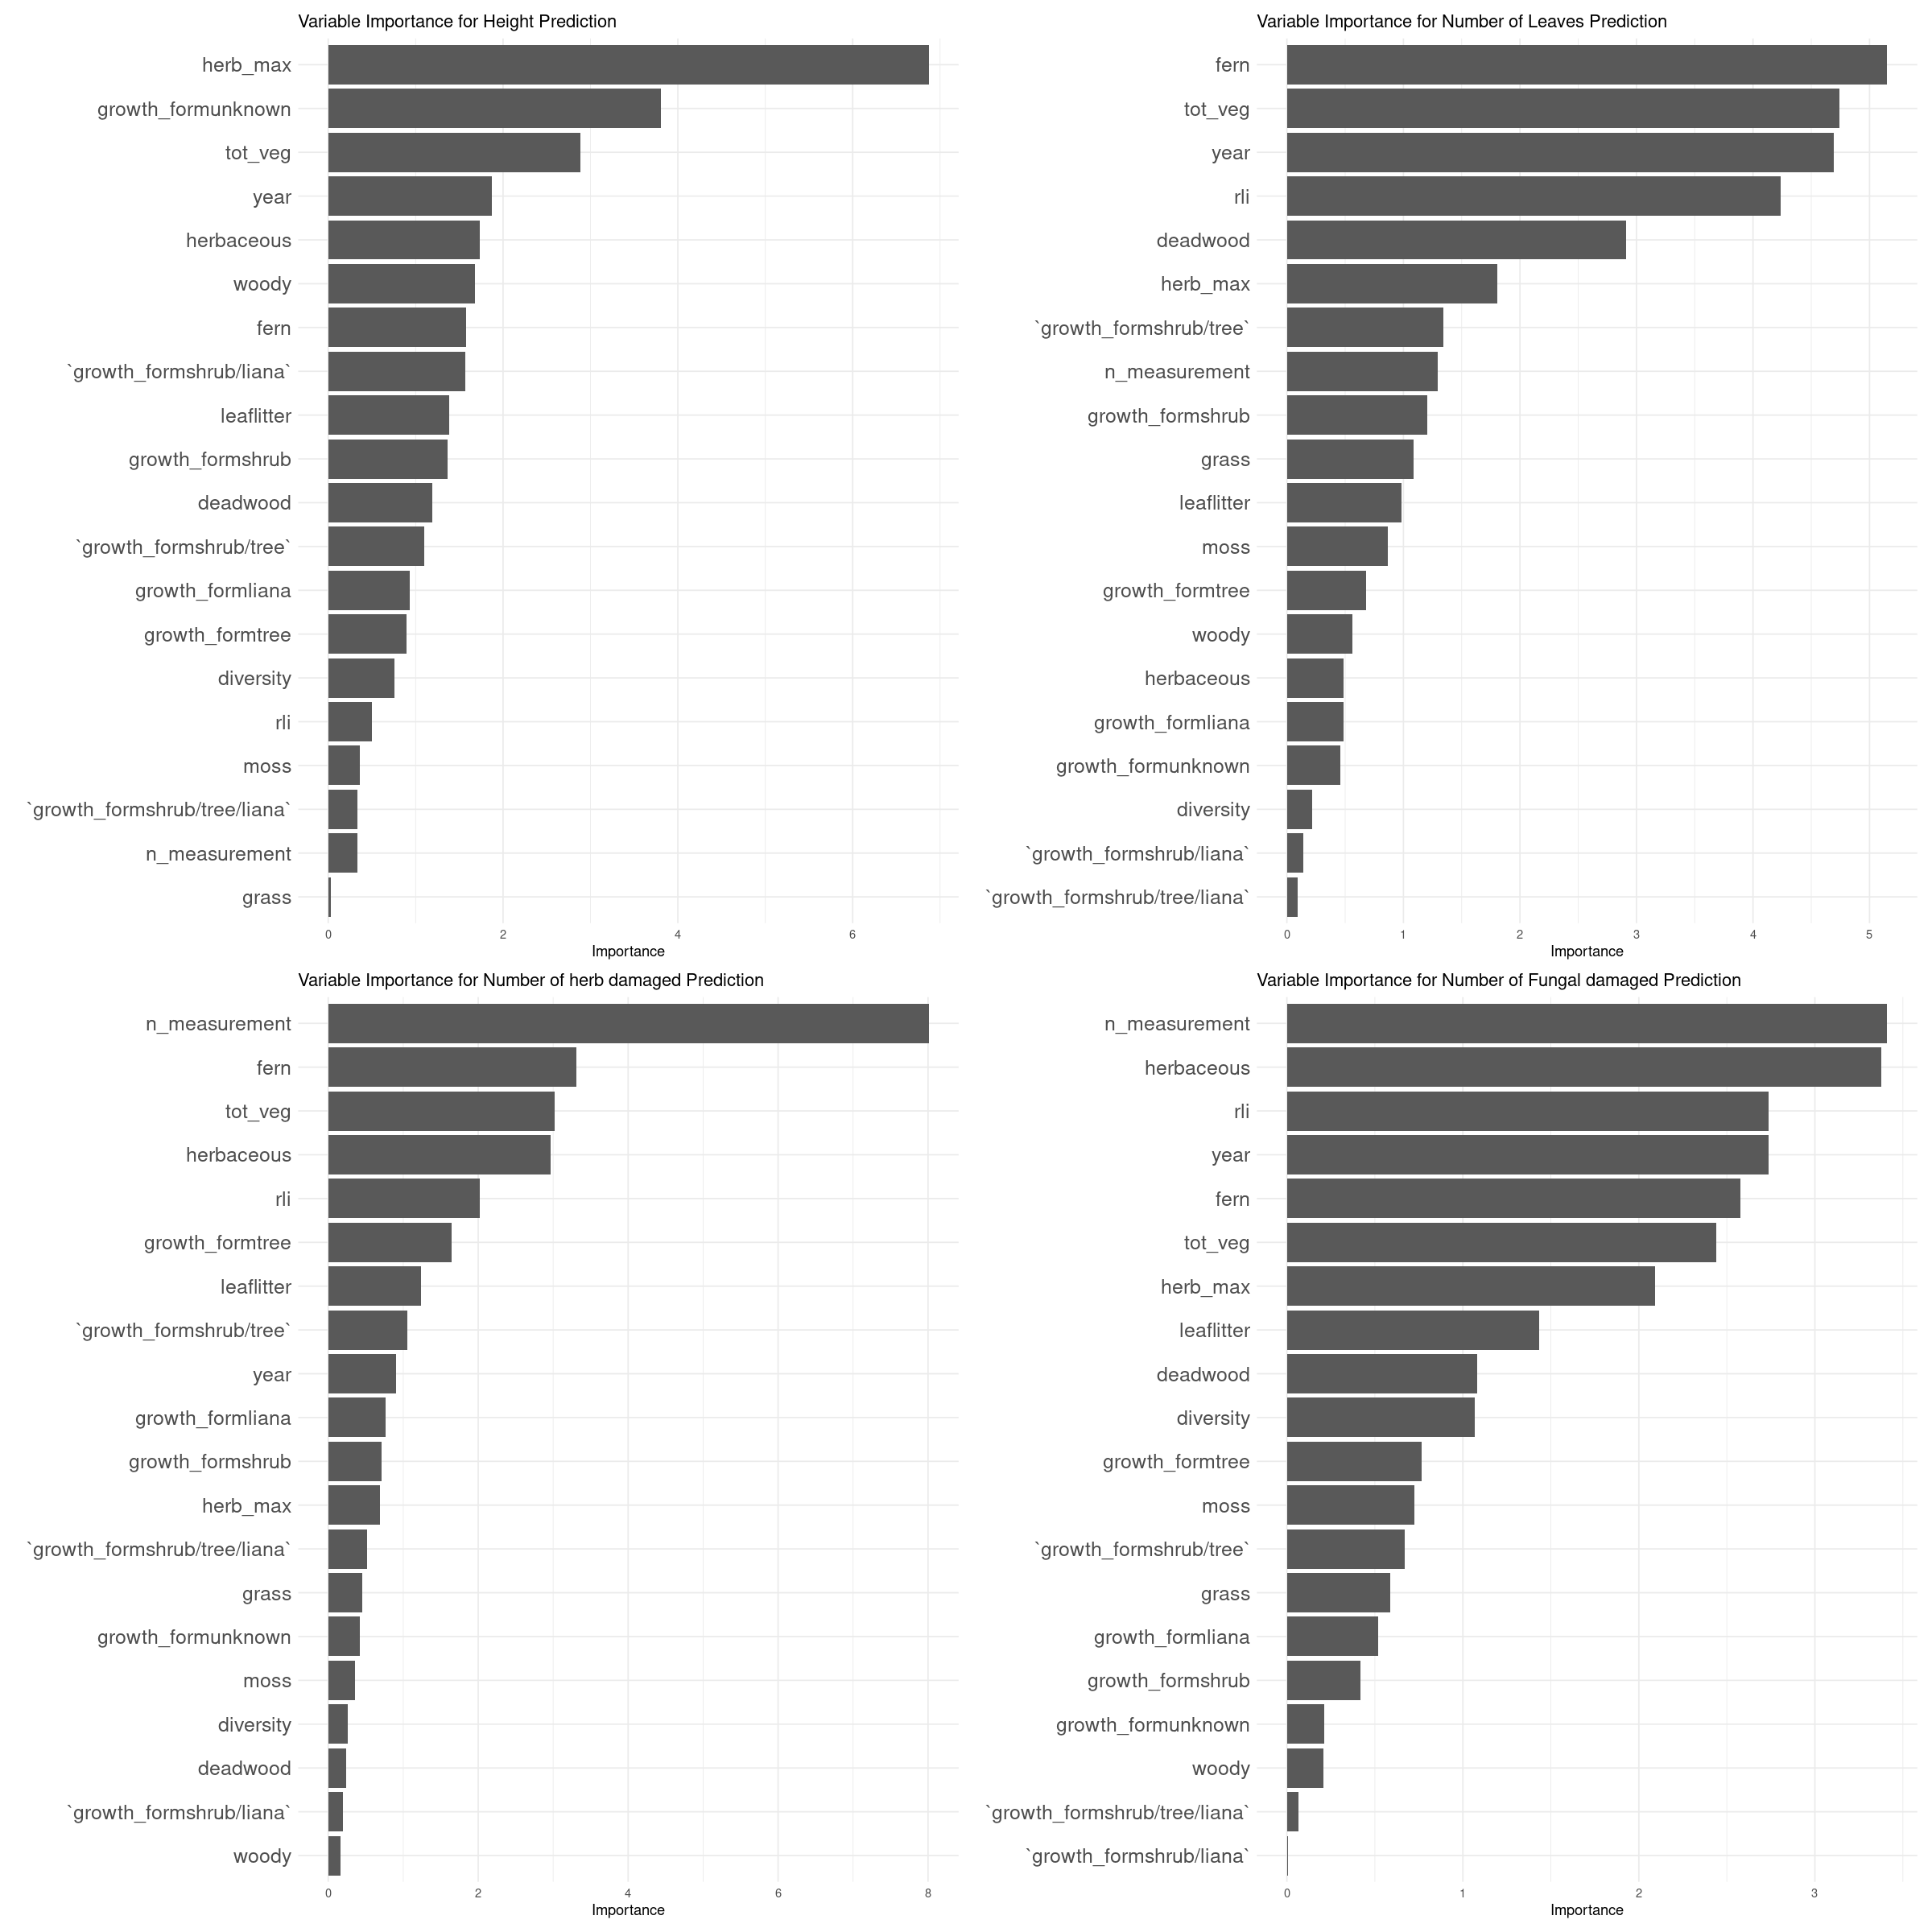

In [30]:
options(repr.plot.width = 20, repr.plot.height = 20)
library(patchwork)
library(ggplot2)

p1 <- p1 + theme(axis.text.y = element_text(size = 15))
p2 <- p2 + theme(axis.text.y = element_text(size = 15))
p3 <- p3 + theme(axis.text.y = element_text(size = 15))
p4 <- p4 + theme(axis.text.y = element_text(size = 15))

p1 + p2 + p3 + p4

- nur tot_veg
- o. Anteil
- die vegetation innerhalb des vegetationsgradienten: extrahiert veg survey daten und dann modelle mit den deckungen; verhältnisse als möglichkeit?)
- bodenvariablen krieg ich auch noch :)
- wie regenerieren unsere gehölze entlang des diversitätsgradienten, existieren die gehölze in der krautschihct die auch gepflanzt wurden?
- wie ist die performance der gehölze gesteuert durch interaktion mit herbivoren und mikroorgs
- kapitel 1/2/3 ; 3 wäre dann was ich jetzt schon gemacht habe

In [31]:
install.packages("naniar")
library(naniar)

# Downloading packages -------------------------------------------------------
- Downloading naniar from CRAN ...              OK [2.6 Mb in 0.19s]
- Downloading norm from CRAN ...                OK [83.9 Kb in 0.28s]
- Downloading visdat from CRAN ...              OK [1.1 Mb in 0.19s]
- Downloading UpSetR from CRAN ...              OK [4.1 Mb in 0.38s]
Successfully downloaded 4 packages in 2.5 seconds.

The following package(s) will be installed:
- naniar [1.1.0]
- norm   [1.0-11.1]
- UpSetR [1.4.0]
- visdat [0.6.0]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing norm ...                           OK [installed binary and cached in 0.57s]
- Installing visdat ...                         OK [installed binary and cached in 0.57s]
- Installing UpSetR ...                         OK [installed binary and cached in 1.3s]
- Installing naniar ...    

In [32]:
all_data_light <- all_data_joined %>%
    left_join(finale_daten %>% select(subplot, rli), by = "subplot")

Warning message in left_join(., finale_daten %>% select(subplot, rli), by = "subplot"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 591 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


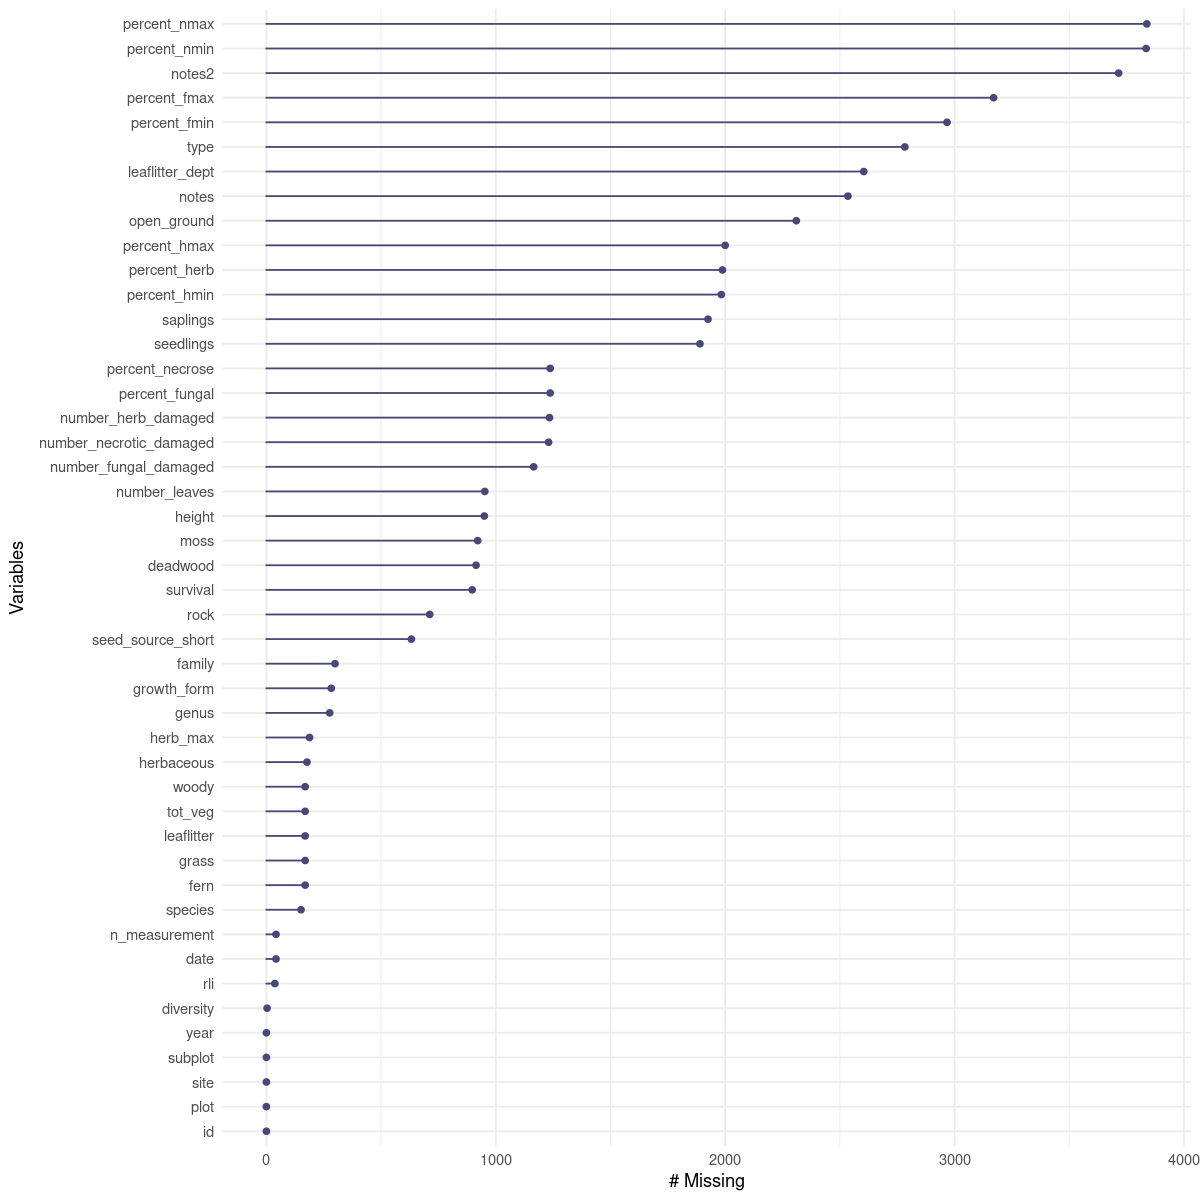

In [33]:
options(repr.plot.width = 10, repr.plot.height = 10)
gg_miss_var(all_data_light)

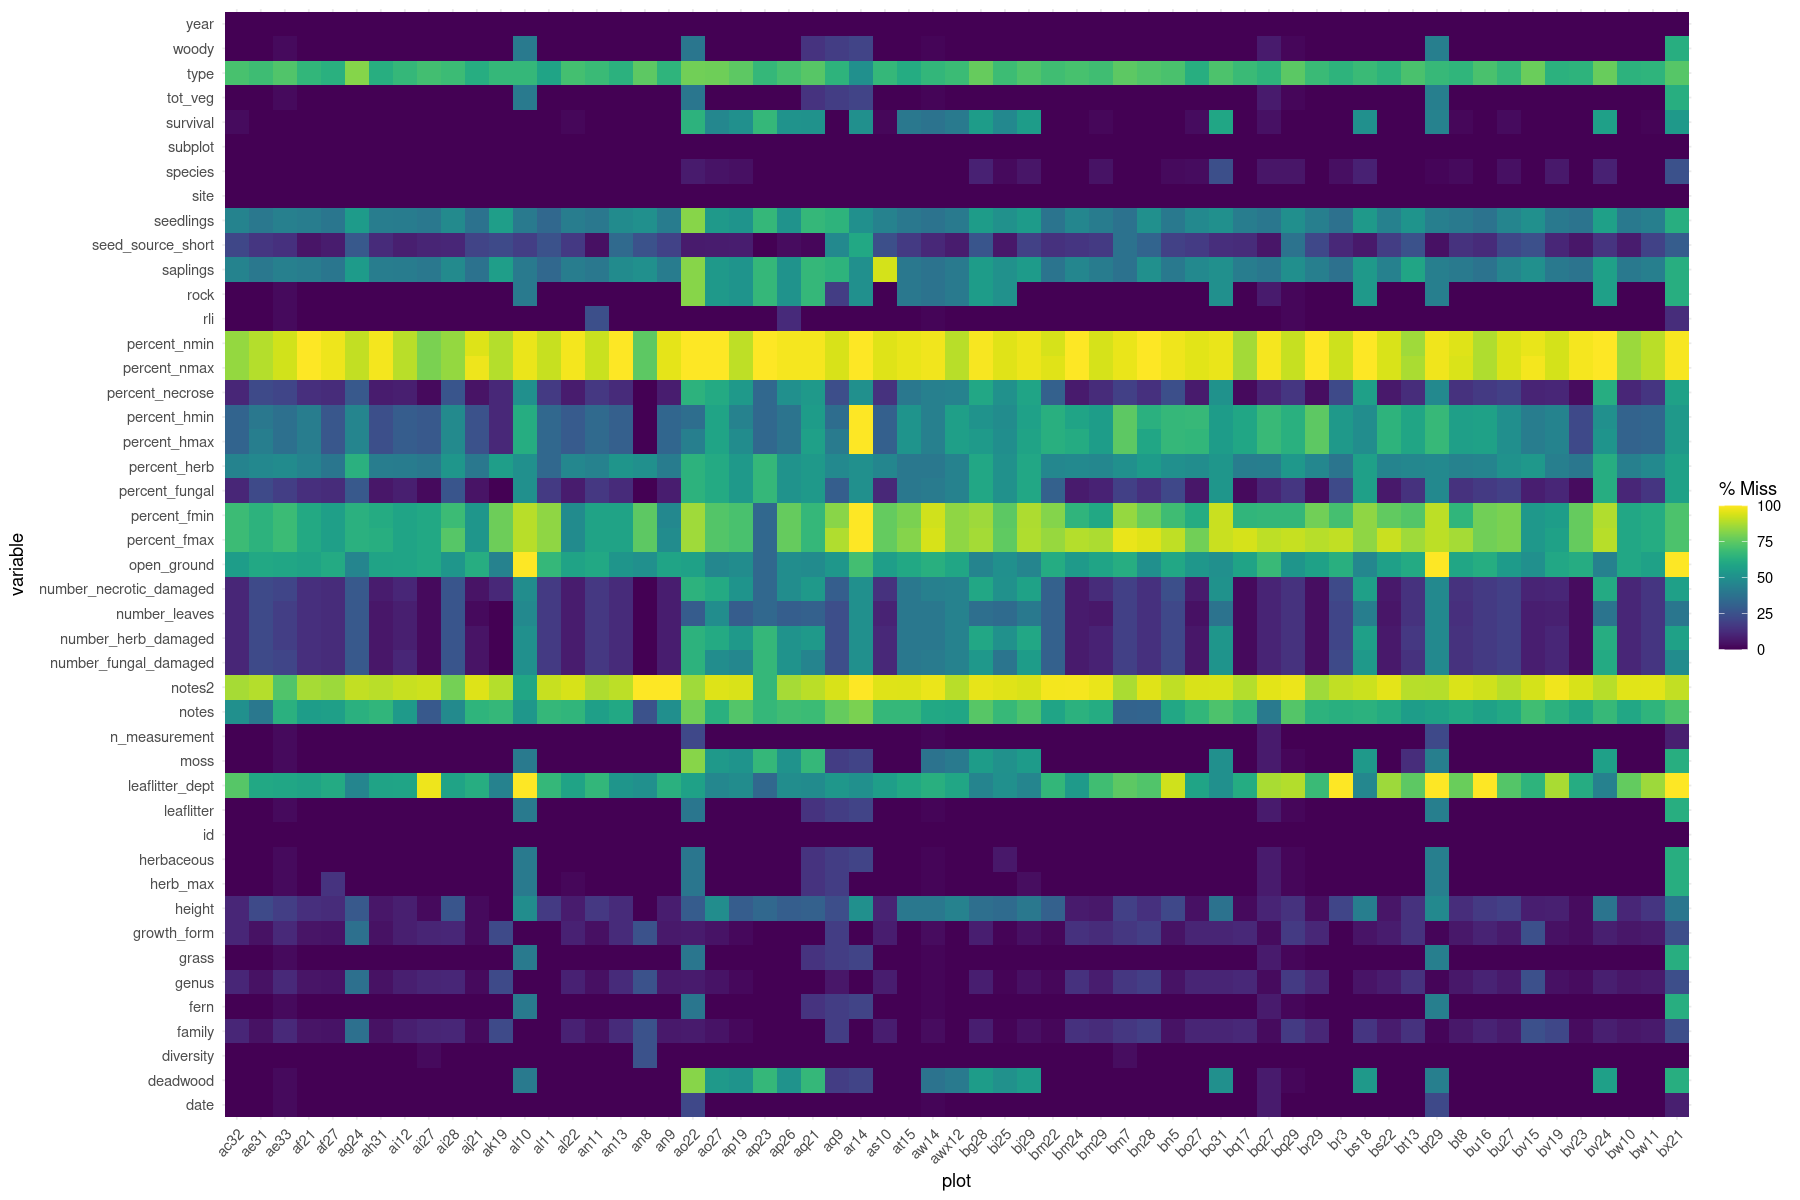

In [34]:
options(repr.plot.width = 15, repr.plot.height = 10)
gg_miss_fct(all_data_light, plot)

nicht die absolute Anzahl der Species richness sondern nur die Gehölze die wir gemessen haben 
-> matteo schreiben